# Customer Churn Prediction — Full ML Pipeline

Predicts which telecom customers are likely to churn using machine learning,
with proper handling of class imbalance via SMOTE.

**Business Problem:** Telecom companies lose significant revenue to customer 
churn. Identifying at-risk customers early allows targeted retention efforts 
(discounts, outreach) before they leave.

**Approach:** Data cleaning → exploratory analysis → SMOTE balancing → 
model comparison (Logistic Regression vs Random Forest) → evaluation with 
accuracy, F1, ROC-AUC, and confusion matrix → feature importance analysis.

**Result:** Random Forest model achieving 77% accuracy and 0.83 ROC-AUC, 
with 70% recall on the churn class — meaning the model catches 7 out of 10 
customers who will actually churn.

# Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load and inspect the data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Shape after cleaning: {df.shape}")
print(f"Churn distribution:\n{df['Churn'].value_counts()}")

Shape after cleaning: (7032, 20)
Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


# EDA Visualization

/tmp/ipykernel_58/472578685.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Churn', 'Churn'])


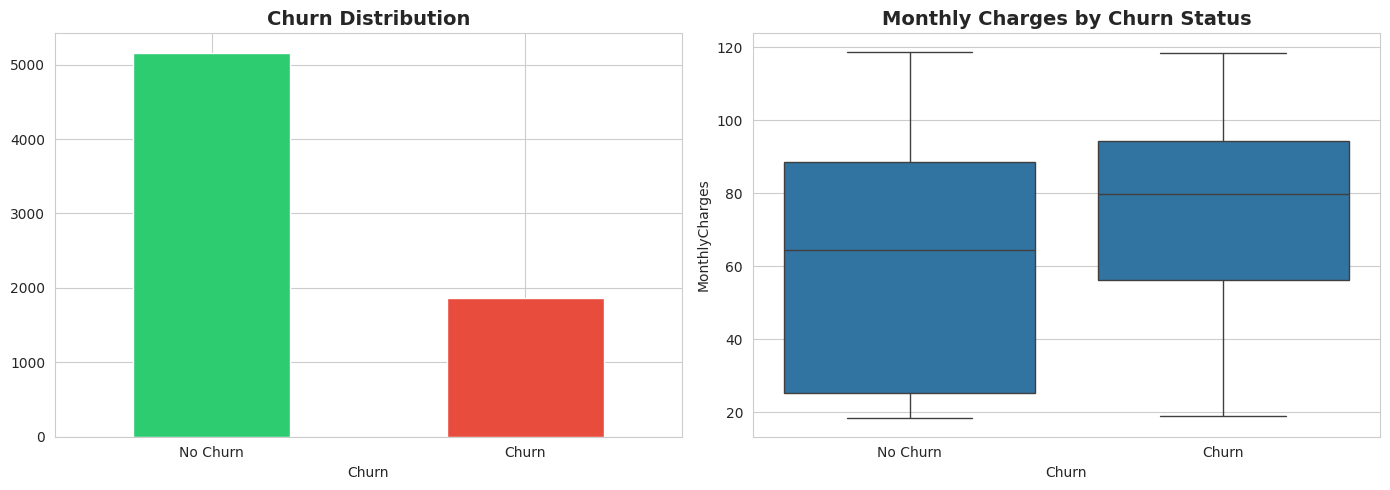

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Encode Categorical Features

In [5]:
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns to encode: {list(categorical_cols)}")

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


# Train/Test Split + Handle Imbalance with SMOTE

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_balanced).value_counts().to_dict()}")

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE: {0: 4130, 1: 4130}


# Train and Compare Models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
}

results = {}
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    print(f"\n{name}")
    print(f"  Accuracy: {results[name]['accuracy']:.3f}")
    print(f"  F1-Score: {results[name]['f1']:.3f}")
    print(f"  ROC-AUC:  {results[name]['roc_auc']:.3f}")


Logistic Regression
  Accuracy: 0.736
  F1-Score: 0.615
  ROC-AUC:  0.833

Random Forest
  Accuracy: 0.768
  F1-Score: 0.617
  ROC-AUC:  0.829


# Confusion Matrix + ROC

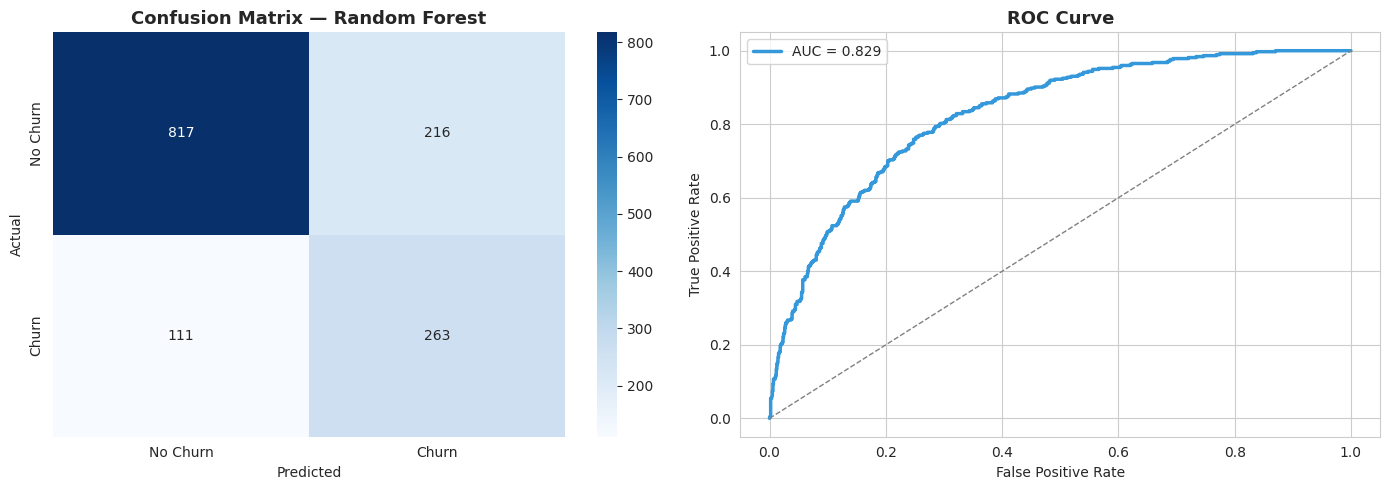


Best model: Random Forest
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.55      0.70      0.62       374

    accuracy                           0.77      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.77      0.78      1407



In [8]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_result = results[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, best_result['y_proba'])
axes[1].plot(fpr, tpr, color='#3498db', lw=2.5, label=f"AUC = {best_result['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest model: {best_model_name}")
print(classification_report(y_test, best_result['y_pred']))

# Feature Importance 

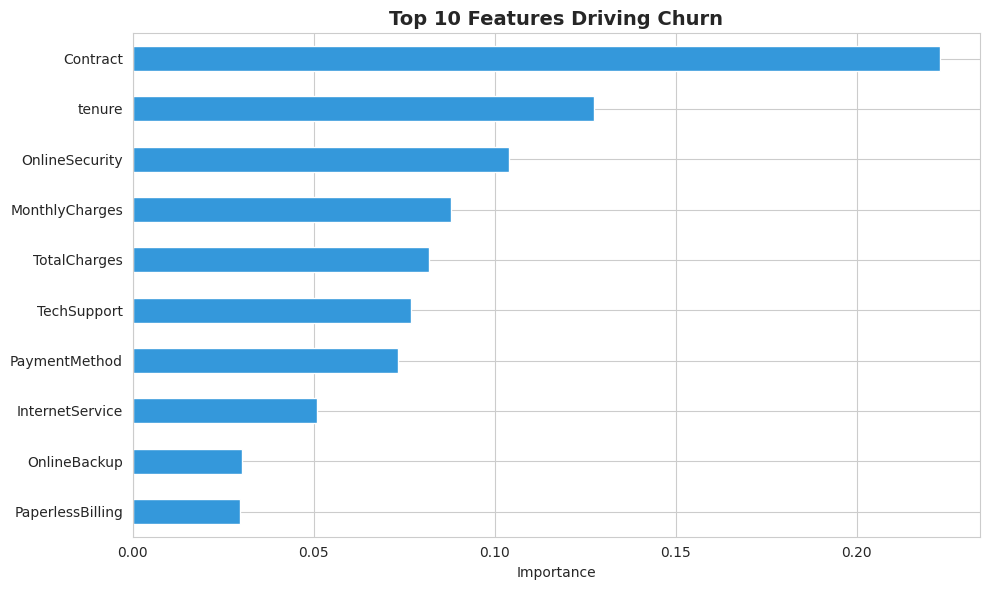

Contract            0.222868
tenure              0.127373
OnlineSecurity      0.103935
MonthlyCharges      0.087976
TotalCharges        0.081705
TechSupport         0.076898
PaymentMethod       0.073373
InternetService     0.050838
OnlineBackup        0.030115
PaperlessBilling    0.029594
dtype: float64


In [9]:
if best_model_name == 'Random Forest':
    importances = pd.Series(best_result['model'].feature_importances_, index=X.columns)
    top_features = importances.sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    top_features.plot(kind='barh', color='#3498db')
    plt.title('Top 10 Features Driving Churn', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(top_features)